<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.4012 acc 0.633 | val loss 0.7937 acc 0.688 *


[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.2554 acc 0.673 | val loss 0.6603 acc 0.753 *


[InceptionNet v3] Epoch   3/100 | LR: 2.85e-04 | train loss 1.2006 acc 0.705 | val loss 0.5772 acc 0.776 *


[InceptionNet v3] Epoch   4/100 | LR: 2.85e-04 | train loss 1.1447 acc 0.711 | val loss 0.5025 acc 0.776 *


[InceptionNet v3] Epoch   5/100 | LR: 2.85e-04 | train loss 1.1585 acc 0.701 | val loss 0.8099 acc 0.671


...

[InceptionNet v3] Epoch  12/100 | LR: 2.85e-04 | train loss 0.9264 acc 0.743 | val loss 0.5537 acc 0.724


[InceptionNet v3] Epoch  13/100 | LR: 2.85e-04 | train loss 0.8976 acc 0.780 | val loss 0.9003 acc 0.629


[InceptionNet v3] Epoch  14/100 | LR: 2.85e-04 | train loss 0.9311 acc 0.753 | val loss 0.5639 acc 0.741


[InceptionNet v3] Epoch  15/100 | LR: 2.85e-04 | train loss 0.8643 acc 0.808 | val loss 0.7139 acc 0.712


[InceptionNet v3] Epoch  16/100 | LR: 2.85e-04 | train loss 0.9333 acc 0.780 | val loss 0.5410 acc 0.771

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 16.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4753)


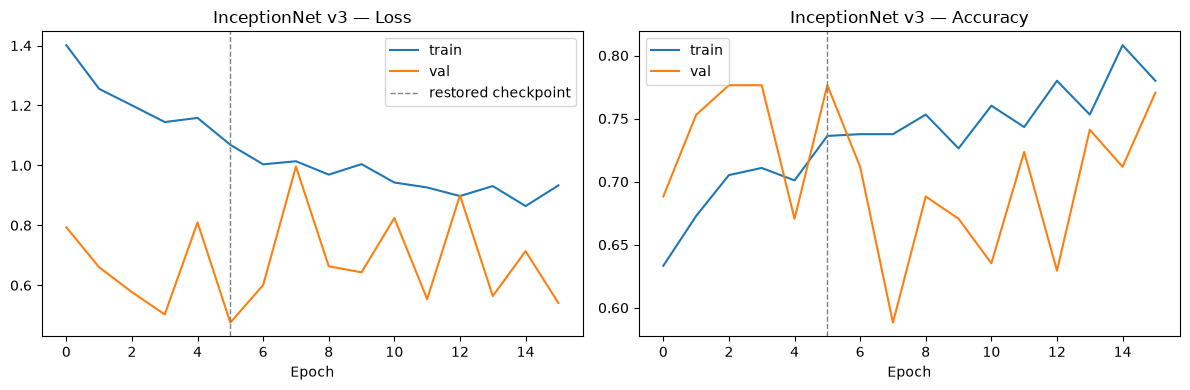

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.414


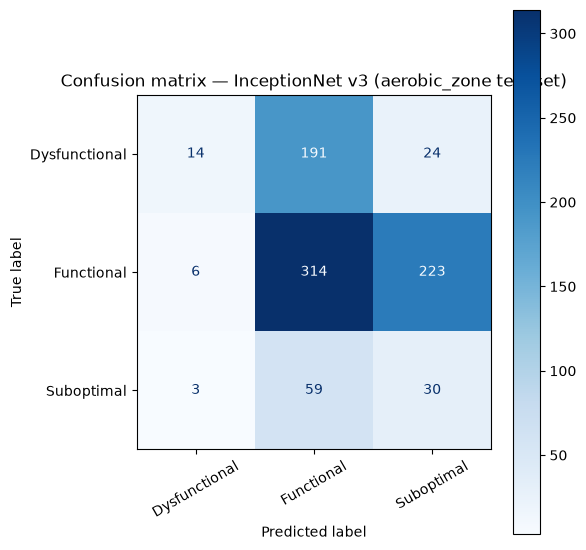

               precision    recall  f1-score   support

Dysfunctional      0.609     0.061     0.111       229
   Functional      0.557     0.578     0.567       543
   Suboptimal      0.108     0.326     0.163        92

     accuracy                          0.414       864
    macro avg      0.425     0.322     0.280       864
 weighted avg      0.523     0.414     0.403       864



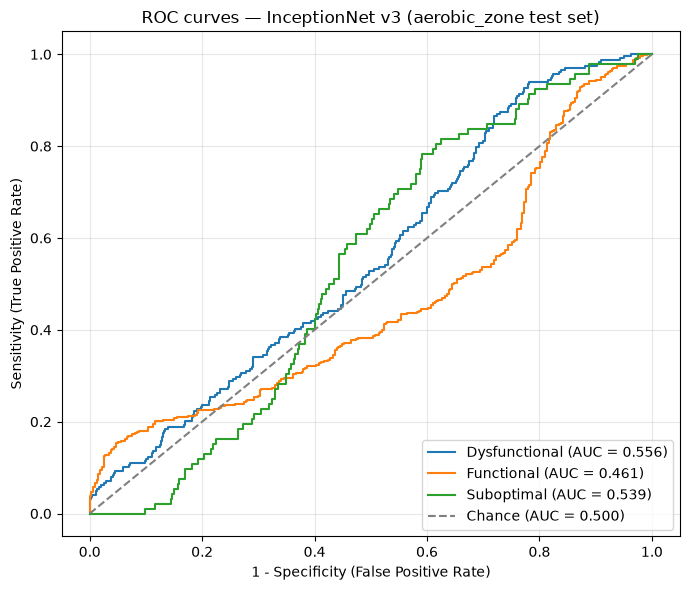

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.556
  Functional     : 0.461
  Suboptimal     : 0.539

Mean AUC (over 3/3 classes with test examples): 0.519


(np.float64(0.41435185185185186),
 {'Dysfunctional': 0.5563318777292576,
  'Functional': 0.4610936128465947,
  'Suboptimal': 0.5391698580761433})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_inception_v3_Waterval.pkl
Saved model weights to ../models/aerobic_zone_inception_v3_cnn.pt
